# EDA — Bitext Retail eCommerce

Este notebook documenta o corpus usado para a classificação de intenções. Os rótulos `category` e `intent` foram publicados pela fonte e são preservados pelo pipeline; não há criação de rótulos por palavras-chave.

> O B2W-Reviews01 continua como fonte complementar de avaliações reais em PT-BR para EDA e análise de feedback. Ele não é a variável-alvo deste classificador.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
DATASET = ROOT / 'data/processed/bitext_retail_intents.parquet'
REPORT = ROOT / 'data/processed/bitext_retail_intents_report.json'
FIGURES = ROOT / 'reports/tp2_data_eda/figures'
FIGURES.mkdir(parents=True, exist_ok=True)
assert DATASET.exists(), 'Execute primeiro: python scripts/build_bitext_intent_dataset.py'
df = pd.read_parquet(DATASET)
df.head()

,record_id,source_dataset,text,category,intent,tags,response,split
0,003079ca817208fff14fc9b4cd0cfe21455211a32e8c1f...,bitext/Bitext-retail-ecommerce-llm-chatbot-tra...,i have to add fucking items to the basket wher...,CART,add_product,BCILMQW,"We're accountable for, and we apologize for an...",test
1,00336bef6d6c3d75a8fba661d11f5bbff664dc6021edb5...,bitext/Bitext-retail-ecommerce-llm-chatbot-tra...,id like to add items to the basket can i get s...,CART,add_product,BCILMPQ,"Sure, I can help you with that! Adding items t...",test
2,0040dff5e511daa7638becdd257237de8374ead4c61217...,bitext/Bitext-retail-ecommerce-llm-chatbot-tra...,i got to add a product to the basket i need as...,CART,add_product,BCQ,I'm here to assist you with adding a product t...,test
3,01065b64e353dc7f03d2d2563a3c83635803df0875194e...,bitext/Bitext-retail-ecommerce-llm-chatbot-tra...,wanna add a product to the cart how could i do it,CART,add_product,BCILPQ,I'm happy to help! I'm here to assist you with...,test
4,014f46e5f2279f316c7574a89ea3059f8dbc740e480caf...,bitext/Bitext-retail-ecommerce-llm-chatbot-tra...,i want assistance adding fucking products to t...,CART,add_product,BMQWZ,We recognize the inconvenience and apologize f...,test


## 1. Estrutura e qualidade

Verificamos dimensão, tipos, valores ausentes, duplicatas exatas e distribuição das partições.

In [2]:
print('Shape:', df.shape)
display(df.dtypes.to_frame('dtype'))
display(df.isna().sum().to_frame('ausentes'))
display(df[['text', 'category', 'intent']].describe(include='all'))
print('Duplicatas exatas:', df.duplicated().sum())
print('Textos idênticos em partições diferentes:', int(df.groupby('text')['split'].nunique().gt(1).sum()))
display(df['split'].value_counts().reindex(['train', 'validation', 'test']).to_frame('registros'))
print('Intenções:', df['intent'].nunique(), '| Categorias:', df['category'].nunique())

Shape: (44884, 8)


,dtype
record_id,object
source_dataset,object
text,object
category,object
intent,object
tags,object
response,object
split,string[python]


,ausentes
record_id,0
source_dataset,0
text,0
category,0
intent,0
tags,0
response,0
split,0


,text,category,intent
count,44884,44884,44884
unique,44674,13,46
top,I'd like to see the fucking status of my reimb...,RETURNS,request_invoice
freq,2,6925,1000


Duplicatas exatas: 0
Textos idênticos em partições diferentes: 0


,registros
split,
train,35906
validation,4489
test,4489


Intenções: 46 | Categorias: 13


## 2. Distribuição dos rótulos

O modelo usará `intent` como variável-alvo. `category` é mantida como uma visão semântica mais ampla para análise e roteamento.

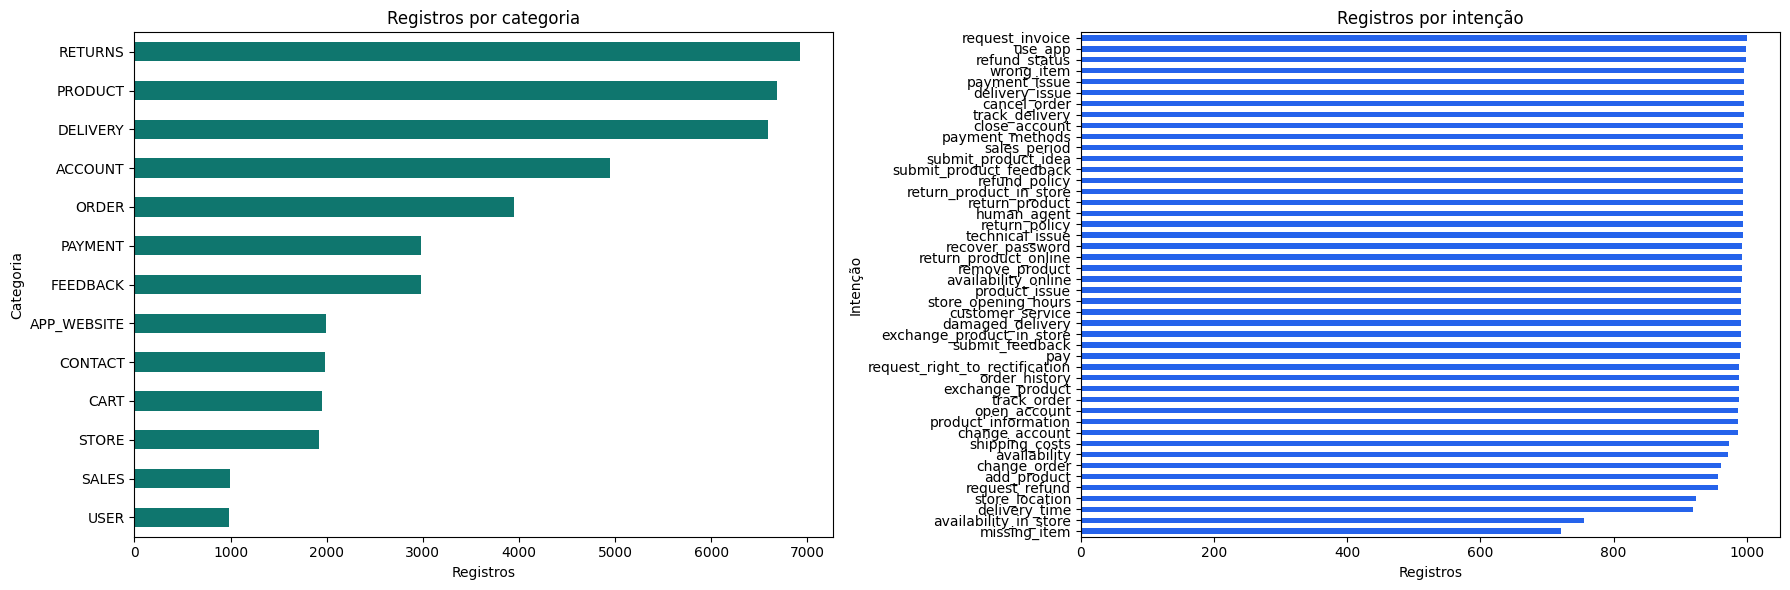

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
df['category'].value_counts().sort_values().plot.barh(ax=axes[0], color='#0f766e')
axes[0].set(title='Registros por categoria', xlabel='Registros', ylabel='Categoria')
df['intent'].value_counts().sort_values().plot.barh(ax=axes[1], color='#2563eb')
axes[1].set(title='Registros por intenção', xlabel='Registros', ylabel='Intenção')
plt.tight_layout()

## 3. Comprimento dos textos e divisão estratificada

A variação de tamanho informa a futura escolha de limite de tokens. O histograma mostra a distribuição; a tabela confirma que cada categoria foi distribuída entre treino, validação e teste.

,caracteres
count,44884.000000
mean,58.313252
std,15.070813
min,3.000000
50%,58.000000
95%,84.000000
max,131.000000


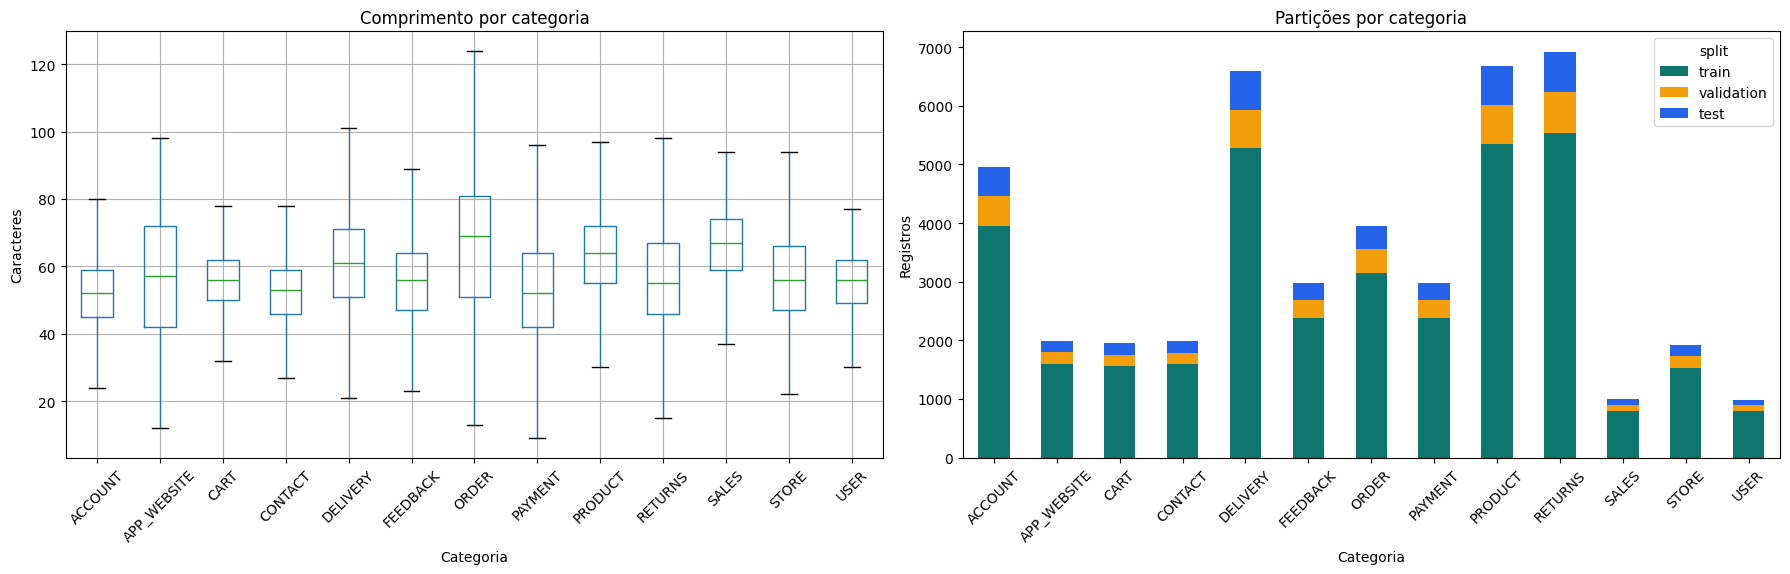

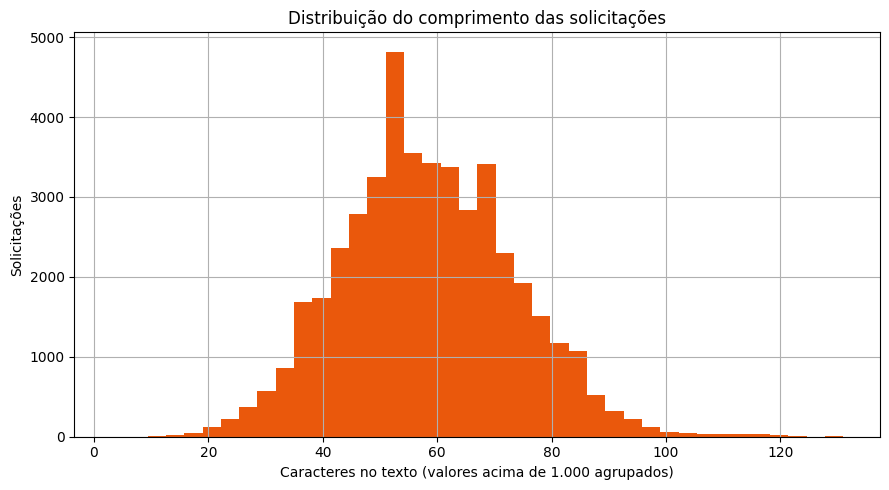

In [4]:
df = df.assign(text_length_chars=df['text'].str.len())
display(df['text_length_chars'].describe(percentiles=[.5, .95]).to_frame('caracteres'))
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
df.boxplot(column='text_length_chars', by='category', rot=45, ax=axes[0], showfliers=False)
axes[0].set(title='Comprimento por categoria', xlabel='Categoria', ylabel='Caracteres')
plt.suptitle('')
pd.crosstab(df['category'], df['split']).reindex(columns=['train', 'validation', 'test']).plot(
    kind='bar', stacked=True, ax=axes[1], color=['#0f766e', '#f59e0b', '#2563eb']
)
axes[1].set(title='Partições por categoria', xlabel='Categoria', ylabel='Registros')
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.figure(figsize=(9, 5))
df['text_length_chars'].clip(upper=1000).hist(bins=40, color='#ea580c')
plt.title('Distribuição do comprimento das solicitações')
plt.xlabel('Caracteres no texto (valores acima de 1.000 agrupados)')
plt.ylabel('Solicitações')
plt.tight_layout()

## 4. Hipóteses

1. Entrega, produto e devoluções concentram uma parcela relevante das solicitações.
2. Solicitações de devolução são mais frequentes do que feedback de produto.
3. Problemas, prazo e rastreamento concentram intenções de entrega.

Também verificamos equilíbrio dos rótulos, presença nas três partições e comprimento dos textos como controles de qualidade.

In [5]:
core = df[df['category'].isin(['DELIVERY', 'PRODUCT', 'RETURNS'])]
intent_counts = df['intent'].value_counts()
category_counts = df['category'].value_counts()
delivery_focus = intent_counts[['delivery_issue', 'delivery_time', 'track_delivery']].sum()
summary = {
    'participação DELIVERY + PRODUCT + RETURNS': f'{len(core) / len(df):.2%}',
    'razão RETURNS/FEEDBACK': round(category_counts['RETURNS'] / category_counts['FEEDBACK'], 2),
    'foco em problemas/prazo/rastreamento na DELIVERY': f"{delivery_focus / category_counts['DELIVERY']:.2%}",
    'menor classe': int(intent_counts.min()),
    'maior classe': int(intent_counts.max()),
    'razão maior/menor': round(intent_counts.max() / intent_counts.min(), 2),
    'intenções em todos os splits': bool((df.groupby('intent')['split'].nunique() == 3).all()),
    'P95 de caracteres': int(df['text_length_chars'].quantile(.95)),
}
pd.Series(summary, name='evidência')

participação DELIVERY + PRODUCT + RETURNS           45.00%
razão RETURNS/FEEDBACK                                2.32
foco em problemas/prazo/rastreamento na DELIVERY    44.15%
menor classe                                           721
maior classe                                          1000
razão maior/menor                                     1.39
intenções em todos os splits                          True
P95 de caracteres                                       84
Name: evidência, dtype: object

## 5. Correlações entre atributos numéricos do texto

O Bitext não tem nota ou valor monetário: suas colunas centrais são texto e rótulos nominais. Por isso, calculamos apenas atributos descritivos genuinamente numéricos. Usamos correlação de Spearman, menos sensível a assimetria e valores extremos. `response` é uma resposta de referência da fonte e **não** entra no classificador de intenção. Não atribuímos números artificiais a `category` ou `intent`.

,count,mean,std,min,50%,95%,max
text_length_chars,44884.0,58.313252,15.070813,3.0,58.0,84.0,131.0
text_words,44884.0,11.801711,2.910465,1.0,12.0,17.0,24.0
question_marks,44884.0,0.353957,0.478201,0.0,0.0,1.0,1.0
response_chars,44884.0,850.892055,313.646079,44.0,836.0,1388.0,2634.0
response_words,44884.0,144.149764,51.359472,9.0,142.0,231.0,415.0


Correlação texto/resposta (caracteres): 0.051


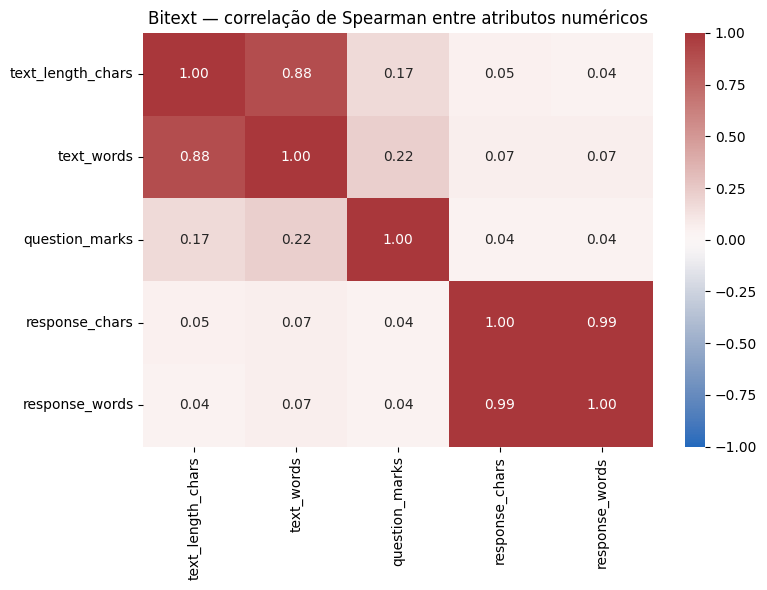

In [6]:
features = df.assign(
    text_words=df['text'].str.split().str.len(),
    question_marks=df['text'].str.count(r'\?'),
    response_chars=df['response'].str.len(),
    response_words=df['response'].str.split().str.len(),
)
numeric_columns = ['text_length_chars', 'text_words', 'question_marks', 'response_chars', 'response_words']
display(features[numeric_columns].describe(percentiles=[.5, .95]).T)
correlations = features[numeric_columns].corr(method='spearman')
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(correlations, annot=True, fmt='.2f', cmap='vlag', center=0, vmin=-1, vmax=1, ax=ax)
ax.set_title('Bitext — correlação de Spearman entre atributos numéricos')
plt.tight_layout()
fig.savefig(FIGURES / '01_bitext_correlacoes.png', dpi=160, bbox_inches='tight')
print('Correlação texto/resposta (caracteres):', round(correlations.loc['text_length_chars', 'response_chars'], 3))

## 6. Relações em scatter plots

O primeiro gráfico mostra **todas as 46 intenções**: mediana versus percentil 95 do comprimento da solicitação. Assim vemos quais intenções têm caudas longas que importam para um futuro limite de tokens. O segundo mostra uma amostra aleatória reprodutível de até 5.000 linhas apenas para evitar sobreposição visual; as estatísticas e correlações acima usam o corpus completo. A resposta é mostrada só como contexto descritivo, nunca como entrada do modelo.

,intent,category,records,median_chars,p95_chars
24,track_order,ORDER,988,65.0,117.0
22,change_order,ORDER,961,79.0,96.0
14,missing_item,DELIVERY,721,75.0,95.0
13,delivery_time,DELIVERY,920,65.0,93.0
36,refund_status,RETURNS,999,64.0,92.1


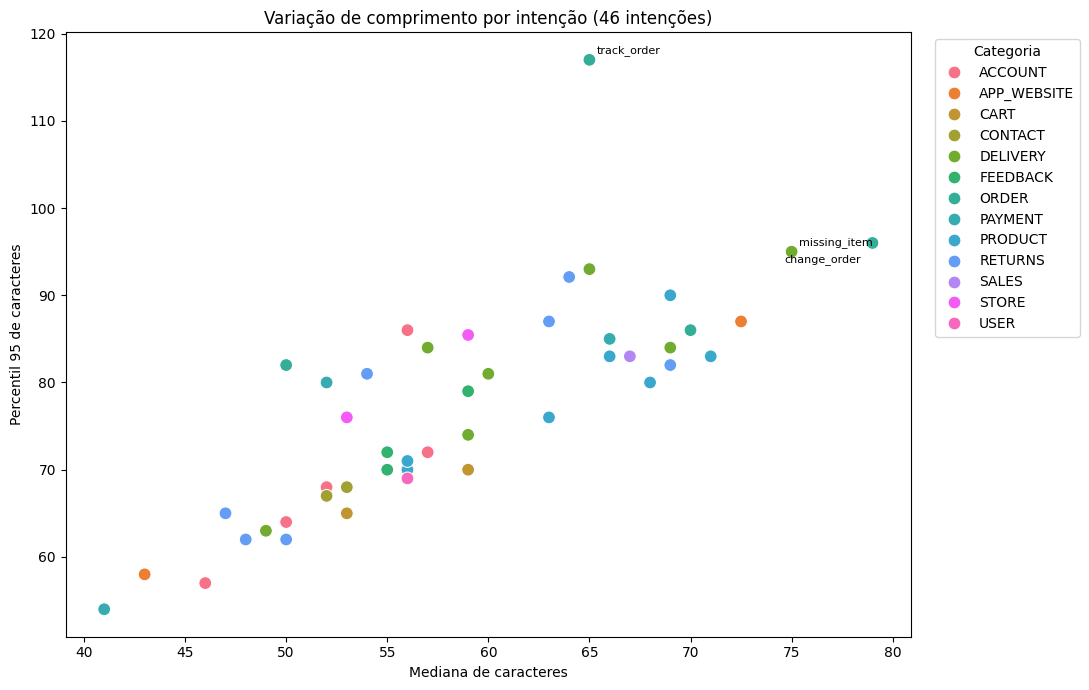

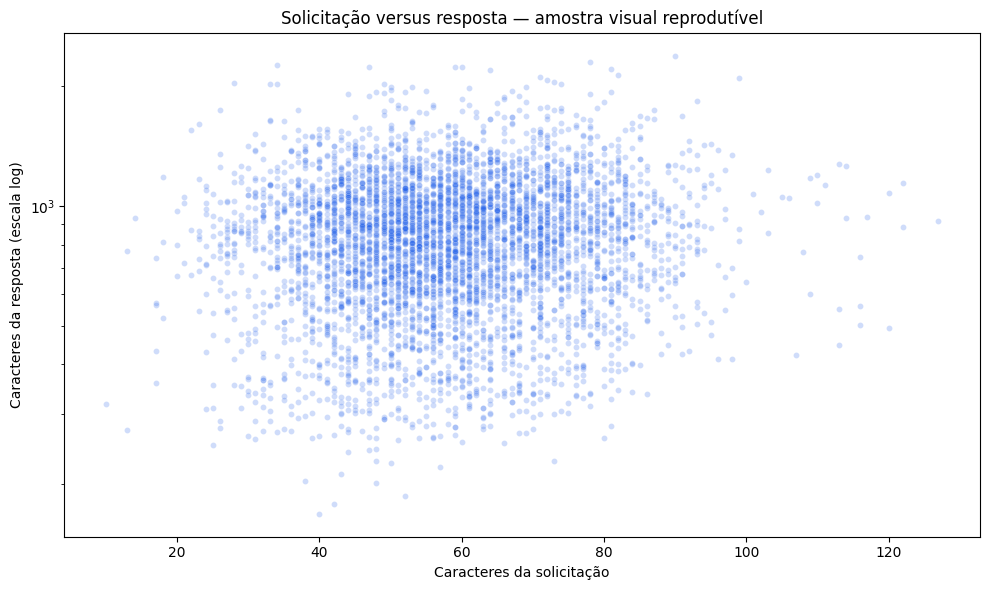

In [7]:
intent_profile = (
    features.groupby(['category', 'intent'], as_index=False)
    .agg(records=('record_id', 'size'),
         median_chars=('text_length_chars', 'median'),
         p95_chars=('text_length_chars', lambda values: values.quantile(.95)))
)
fig, ax = plt.subplots(figsize=(11, 7))
sns.scatterplot(data=intent_profile, x='median_chars', y='p95_chars', hue='category', s=85, ax=ax)
for _, row in intent_profile.nlargest(3, 'p95_chars').iterrows():
    right_edge = row['median_chars'] > 75
    ax.annotate(row['intent'], (row['median_chars'], row['p95_chars']),
                xytext=(-8, -14) if right_edge else (5, 5), textcoords='offset points',
                ha='right' if right_edge else 'left', fontsize=8)
ax.set(xlabel='Mediana de caracteres', ylabel='Percentil 95 de caracteres',
       title='Variação de comprimento por intenção (46 intenções)')
ax.legend(title='Categoria', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
fig.savefig(FIGURES / '02_bitext_intencoes_comprimento.png', dpi=160, bbox_inches='tight')
display(intent_profile.nlargest(5, 'p95_chars')[['intent', 'category', 'records', 'median_chars', 'p95_chars']])
sample = features.loc[features['response_chars'].gt(0)].sample(
    n=min(5_000, int(features['response_chars'].gt(0).sum())), random_state=42
)
fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(data=sample, x='text_length_chars', y='response_chars',
                color='#2563eb', alpha=.22, s=18, ax=ax)
ax.set_yscale('log')
ax.set(xlabel='Caracteres da solicitação', ylabel='Caracteres da resposta (escala log)',
       title='Solicitação versus resposta — amostra visual reprodutível')
plt.tight_layout()
fig.savefig(FIGURES / '03_bitext_solicitacao_resposta.png', dpi=160, bbox_inches='tight')

### Interpretação dos gráficos

- Comprimento em caracteres e em palavras da mesma solicitação têm correlação de Spearman de aproximadamente **0,88**; na resposta, as duas medidas têm correlação próxima de **0,99**. Isso é esperado porque cada par descreve quase a mesma extensão textual, não uma descoberta sobre intenção.
- Comprimento da solicitação e da resposta têm correlação de apenas **0,05**. Neste corpus, uma pergunta mais longa não implica necessariamente uma resposta mais longa. Não há inferência causal aqui, e a resposta publicada pelo Bitext continua fora das entradas do modelo.
- Entre as 46 intenções, `track_order` apresentou o maior percentil 95 de extensão (**117 caracteres**), acima do percentil 95 geral (**84 caracteres**). Um limite de tokens futuro deve ser examinado por intenção, não só pela média global. O scatter individual usa uma amostra visual de 5.000 registros; as estatísticas usam os **44.884** registros.
- O Bitext é em inglês e híbrido/sintético. Estas relações descritivas não demonstram o mesmo comportamento em atendimentos reais em português.

## Conclusão

O Bitext é o corpus rotulado de referência para a tarefa de intenção. O pipeline reprodutível está em `scripts/build_bitext_intent_dataset.py`, e o relatório detalhado está em `reports/bitext_retail_intents/relatorio.md`. A limitação metodológica — fonte híbrida/sintética em inglês — é registrada no README e no relatório.